In [1]:
# CELL 1 - Khởi tạo Spark và Đọc HDFS (Đã cập nhật Tagging)
import os
from functools import reduce
from pyspark.sql import SparkSession
import pyspark.sql.functions as F

try:
    spark.stop()
except:
    pass

spark = (
    SparkSession.builder
    .appName("DemandPredictionFeatureEngineering_GCP")
    .master("yarn")
    .config("spark.submit.deployMode", "client")
    .config("spark.eventLog.enabled", "true")
    .config("spark.executor.instances", "3") 
    .config("spark.executor.cores", "3") 
    .config("spark.executor.memory", "8g") 
    .config("spark.executor.memoryOverhead", "2g") 
    .config("spark.driver.memory", "6g") 
    .config("spark.driver.memoryOverhead", "2g") 
    .config("spark.sql.shuffle.partitions", "18")
    .config("spark.sql.parquet.mergeSchema", "false") # Chống lỗi schema NYC Taxi
    .config("spark.sql.parquet.enableVectorizedReader", "false")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print(f"Spark Session OK | Master: {spark.sparkContext.master}")

# --- KHAI BÁO ĐƯỜNG DẪN CHUẨN ---
BASE_HDFS = "/user/vietanhdata"
# Cấu trúc thư mục tương ứng với nhãn tập dữ liệu
directories = {
    "train": "/user/data/train",
    "val": "/user/data/val",
    "test": "/user/data/test"
}

COLS_SELECT = [
    F.col("PULocationID").cast("long").alias("PULocationID"),
    F.col("tpep_pickup_datetime").cast("timestamp").alias("tpep_pickup_datetime"),
    F.col("tpep_dropoff_datetime").cast("timestamp").alias("tpep_dropoff_datetime"),
    F.col("trip_distance").cast("double").alias("trip_distance"),
    F.col("total_amount").cast("double").alias("total_amount")
]

print("\nĐang quét, đồng bộ Schema và gắn nhãn (Tagging) từ HDFS...")
FileSystem = spark._jvm.org.apache.hadoop.fs.FileSystem
Path = spark._jvm.org.apache.hadoop.fs.Path
fs = FileSystem.get(spark.sparkContext._jsc.hadoopConfiguration())

dfs = []
for split_name, directory in directories.items():
    try:
        status_list = fs.listStatus(Path(directory))
        for file_status in status_list:
            path_str = str(file_status.getPath())
            if path_str.endswith(".parquet"):
                try:
                    # Đọc file, ép kiểu và GẮN NHÃN 'train', 'val' hoặc 'test'
                    df_file = spark.read.parquet(path_str).select(COLS_SELECT).withColumn("split", F.lit(split_name))
                    dfs.append(df_file)
                except Exception as e:
                    print(f"Lỗi đọc file {path_str}: {e}")
    except Exception as e:
        print(f"Lỗi truy cập thư mục {directory}: {e}")

# Gộp dữ liệu
if len(dfs) > 0:
    df_taxi = reduce(lambda a, b: a.union(b), dfs)
    df_taxi = df_taxi.filter((F.year("tpep_pickup_datetime") >= 2020) & (F.year("tpep_pickup_datetime") <= 2025))
    print(f"Tổng số bản ghi (2020-2025): {df_taxi.count():,}")
else:
    print("[LỖI] Không có file nào được đọc!")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/30 12:20:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/30 12:20:54 WARN Client: Neither spark.yarn.jars nor spark.yarn.archive is set, falling back to uploading libraries under SPARK_HOME.


Spark Session OK | Master: yarn

Đang quét, đồng bộ Schema và gắn nhãn (Tagging) từ HDFS...


Tổng số bản ghi (2020-2025): 223,410,839


In [2]:
# CELL 2 - Làm sạch + Lọc Outlier + Trích xuất Time bin 30 phút
df_clean = df_taxi.dropna(subset=["PULocationID", "tpep_pickup_datetime", "tpep_dropoff_datetime"])
df_clean = df_clean.filter(
    (F.col("trip_distance") > 0) &
    (F.col("total_amount") > 0)
)

# Loại bỏ tháng 3, 4, 5, 6 năm 2020 (Dữ liệu ngoại lai COVID-19)
df_clean = df_clean.filter(
    ~((F.year("tpep_pickup_datetime") == 2020) & 
      (F.month("tpep_pickup_datetime").isin(3, 4, 5, 6)))
)

# Tạo time_bin 30 phút
df_clean = df_clean.withColumn(
    "time_bin",
    F.date_trunc("hour", F.col("tpep_pickup_datetime")) + 
    F.expr("INTERVAL 30 MINUTES * FLOOR(MINUTE(tpep_pickup_datetime) / 30)")
)

print(f"Số bản ghi sau làm sạch và lọc outlier: {df_clean.count():,}")

Số bản ghi sau làm sạch và lọc outlier: 212,848,994


In [3]:
# CELL 3 - K-Means Clustering trên dữ liệu tóm tắt (Đã sửa Data Leakage)
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import VectorAssembler

print("Đang tạo bảng tóm tắt đặc trưng cho từng Zone (Chỉ dùng tập TRAIN)...")
# CHỈ DÙNG TẬP TRAIN ĐỂ TRÁNH RÒ RỈ DỮ LIỆU
df_train = df_clean.filter(F.col("split") == "train")

zone_summary_train = df_train.groupBy("PULocationID").agg(
    F.count("*").alias("total_demand"),
    F.avg("trip_distance").alias("avg_distance")
)

assembler = VectorAssembler(inputCols=["total_demand", "avg_distance"], outputCol="features")
zone_summary_vec = assembler.transform(zone_summary_train)

print("Đang huấn luyện mô hình K-Means (K=40 cụm)...")
kmeans = KMeans(k=40, seed=42, featuresCol="features", predictionCol="cluster_id")
kmeans_model = kmeans.fit(zone_summary_vec)

# Lấy nhãn cluster_id đã huấn luyện
clustered_zones = kmeans_model.transform(zone_summary_vec).select("PULocationID", "cluster_id")

# Gán nhãn cluster_id về toàn bộ các Zone của dữ liệu gốc
df_clustered = df_clean.join(clustered_zones, on="PULocationID", how="inner")

print("Hoàn tất gom cụm và gán nhãn cho toàn bộ cuốc xe.")

Đang tạo bảng tóm tắt đặc trưng cho từng Zone (Chỉ dùng tập TRAIN)...
Đang huấn luyện mô hình K-Means (K=40 cụm)...


26/05/30 12:26:12 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


Hoàn tất gom cụm và gán nhãn cho toàn bộ cuốc xe.


In [ ]:
print("Đang tổng hợp Demand theo thời gian và tạo đặc trưng chuỗi thời gian...")

from pyspark.sql.window import Window

# --- BƯỚC 1: Tính Zone-Level Demand ---
zone_demand_df = df_clustered.groupBy("time_bin", "cluster_id", "PULocationID").agg(
    F.count("*").alias("zone_demand"),
    F.first("split").alias("split")
)

# [SỬA LỖI]: Tính target cho cấp độ Zone trên toàn bộ trục thời gian
zone_window = Window.partitionBy("PULocationID").orderBy("time_bin")
zone_demand_df = zone_demand_df.withColumn(
    "true_zone_t_plus_1", F.lead("zone_demand", 1).over(zone_window)
).cache()

# --- BƯỚC 2: Tính Cluster-Level Demand ---
cluster_demand_df = zone_demand_df.groupBy("time_bin", "cluster_id").agg(
    F.sum("zone_demand").alias("cluster_demand"),
    F.first("split").alias("split")
).cache()

# --- BƯỚC 3: Tạo Target t+1 và Đặc trưng độ trễ (Window Function) ---
from pyspark.sql.window import Window

window_spec = Window.partitionBy("cluster_id").orderBy("time_bin")

# Tạo target và các lag features (mỗi khoảng lag là 30 phút)
cluster_demand_with_features = cluster_demand_df.withColumn(
    "target_t_plus_1", F.lead("cluster_demand", 1).over(window_spec)
).withColumn(
    "lag_1", F.lag("cluster_demand", 1).over(window_spec) # Nhu cầu 30 phút trước
).withColumn(
    "lag_2", F.lag("cluster_demand", 2).over(window_spec) # Nhu cầu 1 tiếng trước
).withColumn(
    "lag_3", F.lag("cluster_demand", 3).over(window_spec) # Nhu cầu 1.5 tiếng trước
).withColumn(
    "lag_48", F.lag("cluster_demand", 48).over(window_spec) # Nhu cầu cùng giờ ngày hôm qua (24h = 48 * 30 phút)
).withColumn(
    "lag_336", F.lag("cluster_demand", 336).over(window_spec) # Nhu cầu cùng giờ tuần trước (7 ngày = 336 * 30 phút)
)

# Lọc bỏ các dòng bị Null do quá trình đẩy (lead) và kéo (lag) dữ liệu
cluster_demand_with_target = cluster_demand_with_features.dropna(
    subset=["target_t_plus_1", "lag_1", "lag_2", "lag_3", "lag_48", "lag_336"]
).cache()

print(f"Số bản ghi Cluster-Level (sau khi dropna): {cluster_demand_with_target.count():,}")

# --- BƯỚC 4: Tải xuống Pandas (KIỂM SOÁT) ---
print("Đang tải dữ liệu xuống Pandas...")
sample_count = cluster_demand_with_target.count()

if sample_count > 5_000_000:
    print(f"⚠️ {sample_count:,} rows - lấy 1% sample để tránh OOM")
    pdf_cluster = cluster_demand_with_target.sample(fraction=0.01).toPandas()
else:
    pdf_cluster = cluster_demand_with_target.toPandas()

pdf_zone = zone_demand_df.toPandas()

print(f"Cluster data: {pdf_cluster.shape}, Zone data: {pdf_zone.shape}")

# --- BƯỚC 5: Tính tỷ trọng phân rã (Disaggregation Ratios) ---
print("Đang tính tỷ trọng phân rã (từ TRAIN data)...")

zone_demand_train = zone_demand_df.filter(F.col("split") == "train")

zone_total = zone_demand_train.groupBy("cluster_id", "PULocationID").agg(
    F.sum("zone_demand").alias("zone_total")
)

cluster_total = zone_demand_train.groupBy("cluster_id").agg(
    F.sum("zone_demand").alias("cluster_total")
)

ratios_spark = zone_total.join(
    cluster_total, on="cluster_id", how="inner"
).withColumn(
    "proportion",
    F.col("zone_total") / F.col("cluster_total")
).select("cluster_id", "PULocationID", "proportion")

zone_ratios = ratios_spark.toPandas()
print(f"Zone ratios shape: {zone_ratios.shape}")

# --- BƯỚC 6: Lưu Spark DataFrames ---
cluster_demand_with_target.write.mode("overwrite").parquet(
    "hdfs:///user/vietanhdata/cluster_demand_features"
)
print("✅ Đã lưu cluster_demand_features vào HDFS")

Đang tổng hợp Demand theo thời gian và tạo đặc trưng chuỗi thời gian...


26/05/30 12:29:17 WARN DAGScheduler: Broadcasting large task binary with size 1827.2 KiB
26/05/30 12:30:07 WARN DAGScheduler: Broadcasting large task binary with size 1834.8 KiB
26/05/30 12:30:10 WARN DAGScheduler: Broadcasting large task binary with size 1841.0 KiB
26/05/30 12:30:13 WARN DAGScheduler: Broadcasting large task binary with size 1842.4 KiB
26/05/30 12:30:14 WARN DAGScheduler: Broadcasting large task binary with size 1857.4 KiB
26/05/30 12:30:18 WARN DAGScheduler: Broadcasting large task binary with size 1862.1 KiB


Số bản ghi Cluster-Level (sau khi dropna): 3,829,836
Đang tải dữ liệu xuống Pandas...


26/05/30 12:30:19 WARN DAGScheduler: Broadcasting large task binary with size 1862.1 KiB
26/05/30 12:30:22 WARN DAGScheduler: Broadcasting large task binary with size 1859.2 KiB
26/05/30 12:32:42 WARN DAGScheduler: Broadcasting large task binary with size 1830.1 KiB


In [ ]:
# CELL 5 - Cài đặt thư viện ML
import os, glob

offline_dir = "/workspace/code/taxiflow_nyc/offline_packages"
if os.path.exists(offline_dir) and glob.glob(os.path.join(offline_dir, "*.whl")):
    print("Cài offline...")
    !pip install --no-index --find-links=file://{offline_dir} scikit-learn xgboost pandas
else:
    print("Cài online...")
    !pip install scikit-learn xgboost joblib pyarrow pandas

Cài online...


In [ ]:
# CELL 6 - Lưu Data (CSV LOCAL + HDFS)
import os

print("Đang lưu dữ liệu...")

# 1. Lưu CSV local (đầu tiên vì quan trọng)
# local_csv_dir = '/workspace/data'
# os.makedirs(local_csv_dir, exist_ok=True)

# pdf_cluster.to_csv(f'{local_csv_dir}/taxi_demand_cluster_features.csv', index=False)
# pdf_zone.to_csv(f'{local_csv_dir}/taxi_demand_zone_features.csv', index=False)
# print(f"✅ Lưu CSV local:")
# print(f"  - {local_csv_dir}/taxi_demand_cluster_features.csv ({pdf_cluster.shape})")
# print(f"  - {local_csv_dir}/taxi_demand_zone_features.csv ({pdf_zone.shape})")

# 2. Lưu HDFS Parquet (sử dụng HDFS path từ Cell 4)
# ⚠️ Cell 4 đã lưu, Cell 6 chỉ lưu lại nếu cần update
BASE_HDFS = "/user/vietanhdata"
hdfs_path = f"{BASE_HDFS}/cluster_demand_features"

# Kiểm tra nếu cần lưu lại
try:
    cluster_demand_df.write.mode("overwrite").parquet(hdfs_path)
    print(f"✅ Lưu HDFS: {hdfs_path}")
except Exception as e:
    print(f"⚠️ Lưu HDFS thất bại: {e}")
    print("  (Có thể đã lưu ở Cell 4)")

Đang lưu dữ liệu...


26/05/30 05:45:34 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB


✅ Lưu HDFS: /user/vietanhdata/cluster_demand_features


In [ ]:
# CELL 7 - Chuẩn bị ML Data với LAG FEATURES
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd

print("Đang bóc tách đặc trưng thời gian...")

# 1. Trích xuất đặc trưng thời gian
pdf_cluster['hour'] = pdf_cluster['time_bin'].dt.hour
pdf_cluster['day_of_week'] = pdf_cluster['time_bin'].dt.dayofweek
pdf_cluster['month'] = pdf_cluster['time_bin'].dt.month

# ✅ THÊM MỚI: Tạo đặc trưng ngày nghỉ cuối tuần (Thứ 7 = 5, CN = 6)
pdf_cluster['is_weekend'] = (pdf_cluster['day_of_week'] >= 5).astype(int)

pdf_cluster = pdf_cluster.sort_values('time_bin')

# 2. Chia tập bằng cột Tagging (từ HDFS)
train_data = pdf_cluster[pdf_cluster['split'] == 'train'].copy()
val_data = pdf_cluster[pdf_cluster['split'] == 'val'].copy()
test_data = pdf_cluster[pdf_cluster['split'] == 'test'].copy()

# ✅ UPDATED: Bao gồm lag features và is_weekend
features = [
    'cluster_id',        # Mã cụm
    'hour',              # 0-23
    'day_of_week',       # 0-6
    'is_weekend',        # 0 (ngày thường) hoặc 1 (cuối tuần)
    'month',             # 1-12
    'cluster_demand',    # Nhu cầu hiện tại (t)
    'lag_1',             # 30 phút trước
    'lag_2',             # 1 tiếng trước
    'lag_3',             # 1.5 tiếng trước
    'lag_48',            # Cùng giờ hôm qua
    'lag_336'            # Cùng giờ tuần trước
]

# Kiểm tra và xử lý NaN an toàn
print("Kiểm tra giá trị rỗng (NaN) trong tập dữ liệu:")
for f in features:
    nan_count = train_data[f].isna().sum()
    if nan_count > 0:
        print(f"  ⚠️ {f}: {nan_count} NaNs → Đang loại bỏ...")
        train_data = train_data.dropna(subset=[f])
        val_data = val_data.dropna(subset=[f])
        test_data = test_data.dropna(subset=[f])

# Định nghĩa tập Dữ liệu đầu vào (X) và Mục tiêu (y)
X_train, y_train = train_data[features], train_data['target_t_plus_1']
X_val, y_val = val_data[features], val_data['target_t_plus_1']
X_test, y_test = test_data[features], test_data['target_t_plus_1']

print(f"\n✅ Danh sách Features ({len(features)} biến): {features}")
print(f"Kích thước tập - Train: {X_train.shape}, Valid: {X_val.shape}, Test: {X_test.shape}")

# 3. Hàm đánh giá (Giữ nguyên gốc của bạn)
def evaluate_disaggregated_model(model_name, model, X_eval, eval_base_df, pdf_zone_hist, ratios_df):
    pred_cluster = model.predict(X_eval)
    eval_df_copy = eval_base_df.copy()
    eval_df_copy['pred_cluster_demand'] = pred_cluster

    # ✅ LẤY SPLIT TỪ eval_base_df
    split_name = eval_df_copy['split'].iloc[0]
    
    # ✅ FILTER pdf_zone_hist THEO SPLIT
    pdf_zone_filtered = pdf_zone_hist[pdf_zone_hist['split'] == split_name].copy()

    eval_zone = pdf_zone_filtered.merge(
        eval_df_copy[['time_bin', 'cluster_id', 'pred_cluster_demand']], 
        on=['time_bin', 'cluster_id'], how='inner'
    )
    eval_zone = eval_zone.merge(ratios_df, on=['cluster_id', 'PULocationID'], how='left')
    eval_zone['pred_zone_demand'] = eval_zone['pred_cluster_demand'] * eval_zone['proportion']

    eval_zone = eval_zone.sort_values(['PULocationID', 'time_bin'])
    eval_zone = eval_zone.dropna(subset=['true_zone_t_plus_1', 'pred_zone_demand'])

    y_true = eval_zone['true_zone_t_plus_1']
    y_pred = eval_zone['pred_zone_demand']
    
    y_true_safe = np.where(y_true == 0, 1e-6, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- {model_name} ({split_name.upper()}) (Zone-Level) ---")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MAPE : {mape:.4f}%")
    print(f"R2   : {r2:.4f}\n")

Train: (2480183, 5), Valid: (388593, 5), Test: (841775, 5)


In [ ]:
# CELL 8 - Linear Regression (Đã sửa TimeSeriesSplit)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.linear_model import LinearRegression

print("Huấn luyện Linear Regression (Cluster-Level)...")

# Khởi tạo chia tập Validation theo chuỗi thời gian
tscv = TimeSeriesSplit(n_splits=3)

lr_grid = GridSearchCV(
    LinearRegression(),
    {'fit_intercept': [True, False]},
    cv=tscv,  # ✅ Đã thay số 5 bằng tscv
    scoring='neg_mean_squared_error'
)
lr_grid.fit(X_train, y_train)
lr_best = lr_grid.best_estimator_

print("Tham số tốt nhất:", lr_grid.best_params_)

# Đánh giá trên tập Test
evaluate_disaggregated_model("Linear Regression", lr_best, X_test, test_data, pdf_zone, zone_ratios)

Huấn luyện Linear Regression (Cluster-Level)...
--- Linear Regression (Zone-Level) ---
RMSE : 14.3457
MAE  : 6.2636
MAPE : 65.8318%
R2   : 0.8651



In [ ]:
# CELL 9 - Random Forest (Đã sửa TimeSeriesSplit)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

print("Huấn luyện Random Forest (Cluster-Level)...")

# Khởi tạo chia tập Validation theo chuỗi thời gian
tscv = TimeSeriesSplit(n_splits=3)

rf_random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    {'n_estimators': [50, 100], 'max_depth': [10, 20], 'min_samples_split': [5, 10]},
    n_iter=3, 
    cv=tscv,  # ✅ Đã thay số 3 bằng tscv
    scoring='neg_mean_squared_error', 
    random_state=42, 
    n_jobs=-1
)
rf_random.fit(X_train, y_train)
rf_best = rf_random.best_estimator_

print("Tham số tốt nhất:", rf_random.best_params_)

# Đánh giá trên tập Test
evaluate_disaggregated_model("Random Forest", rf_best, X_test, test_data, pdf_zone, zone_ratios)

Huấn luyện Random Forest (Cluster-Level)...
--- Random Forest (Zone-Level) ---
RMSE : 13.9058
MAE  : 6.0235
MAPE : 62.1806%
R2   : 0.8732



In [ ]:
# CELL 10 - XGBoost (Tối ưu với Early Stopping trên tập Validation)
import xgboost as xgb

print("Huấn luyện XGBoost (Cluster-Level) với Early Stopping...")

# 1. Khởi tạo mô hình trực tiếp (Không dùng RandomizedSearchCV nữa để làm chủ hoàn toàn quá trình)
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,        # Cứ cho max 500 cây, Early stopping sẽ tự ngắt sớm
    learning_rate=0.05,
    max_depth=7,
    random_state=42,
    n_jobs=-1
)

# 2. Đưa tập Validation vào làm giám thị (eval_set)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)], # Cho giám sát cả điểm train và val
    early_stopping_rounds=20,                      # Nếu 20 vòng không cải thiện thì dừng
    verbose=50                                     # In kết quả sau mỗi 50 cây
)

print(f"\n✅ Đã dừng ở cây thứ: {xgb_model.best_iteration}")

# 3. Đánh giá trên tập Test
evaluate_disaggregated_model("XGBoost", xgb_model, X_test, test_data, pdf_zone, zone_ratios)

Huấn luyện XGBoost (Cluster-Level)...
--- XGBoost (Zone-Level) ---
RMSE : 14.0845
MAE  : 6.0578
MAPE : 62.6634%
R2   : 0.8700



Đang vẽ Feature Importance Chart...
Feature Importance:
          Feature  Importance
4  cluster_demand    0.974223
3           month    0.012090
1            hour    0.006249
0      cluster_id    0.004507
2     day_of_week    0.002932



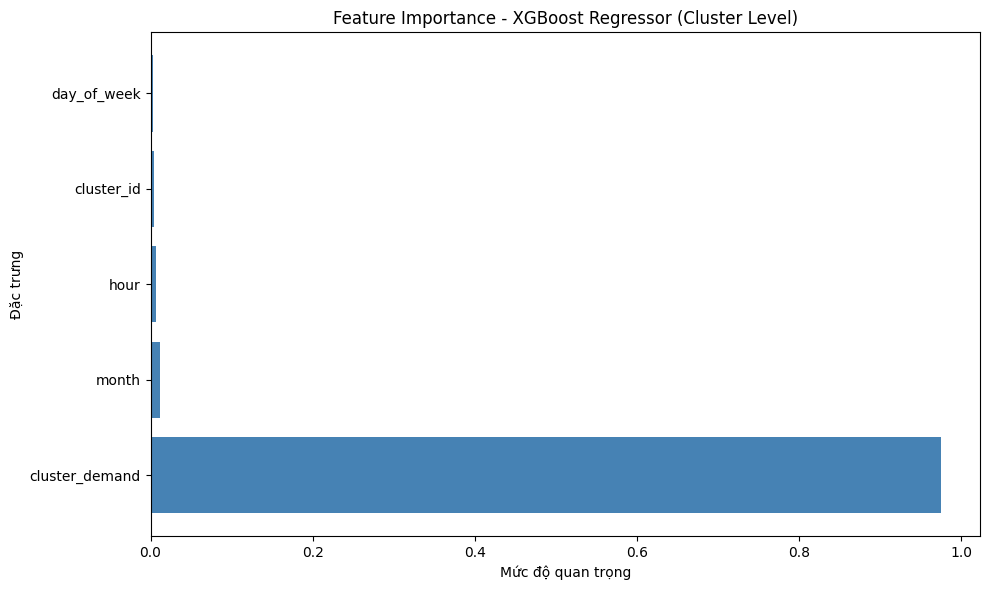

In [ ]:
# CELL 11 - Feature Importance (Fixed)
import matplotlib.pyplot as plt
import pandas as pd  # ✅ THÊM DÒNG NÀY
import os

print("Đang vẽ Feature Importance Chart...")

# 1. Tạo thư mục nếu chưa tồn tại
# output_dir = '/workspace/data'
# os.makedirs(output_dir, exist_ok=True)

# 2. Chuẩn bị dữ liệu
try:
    feature_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_  # ✅ Sửa xgb_best → xgb_model
    }).sort_values('Importance', ascending=False)
    print(f"Feature Importance:\n{feature_df}\n")
except Exception as e:
    print(f"❌ Lỗi tạo DataFrame: {e}")
    raise

# 3. Vẽ biểu đồ
try:
    plt.figure(figsize=(10, 6))
    plt.barh(feature_df['Feature'], feature_df['Importance'], color='steelblue')
    plt.xlabel('Mức độ quan trọng')
    plt.ylabel('Đặc trưng')
    plt.title('Feature Importance - XGBoost Regressor (Cluster Level)')
    plt.tight_layout()
    
    # 4. Lưu biểu đồ
    # output_path = f'{output_dir}/feature_importance.png'
    # plt.savefig(output_path, dpi=300, bbox_inches='tight')
    # print(f"✅ Biểu đồ đã lưu: {output_path}")
    # print(f"   Size: {os.path.getsize(output_path) / 1024:.1f}KB")
    
    # 5. Hiển thị
    plt.show()
    
except ImportError as e:
    print(f"❌ Lỗi import: {e}")
    print("   Giải pháp: Chạy Cell 5 để cài matplotlib")
    raise
except Exception as e:
    print(f"❌ Lỗi vẽ biểu đồ: {e}")
    raise

In [ ]:
# # CELL 12 - Lưu model
# import joblib

# model_filename = '/workspace/data/taxi_demand_xgboost_model.pkl'
# joblib.dump(xgb_best, model_filename)
# print(f"Đã lưu model tại: {model_filename}")